# Homogeneous Isotropic Source Cruciform With Shielding

In [141]:
import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import c5g7 #cross section placeholder
from ttnte.cad.curves import qtrlobe
from ttnte.iga import IGAMesh
from ttnte.sources import IsotropicInternalSource
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source

tn.set_default_dtype(tn.float64)
tn.set_num_threads(14)

In [142]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = c5g7()

In [143]:
## Initialize dimensional variables
X = 1.6 # Channel pitch

# Cruciform
R = 0.297 # Radius defining valleys of fixed source
delta = 0.306 # Width of lobes
d2 = delta * 0.5 # Half width of lobes
x = 0.18 # Portrusion of lobes

# Shielding
I = 0.7 # Inner radius
O = 0.75 # Outer radius

In [144]:
# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
cruciform = qtrlobe(outrad = R, portrs = x, hfwidth = d2)
circleI = cad.circle(radius = I, angle = [np.pi/2, 0] )
circleO = cad.circle(radius = O, angle = [np.pi/2, 0] )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [145]:
# NURBS patches
patches = {}
source_pids = []
pid = 0
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    csec = origin.slice(0, sections[i], sections[i + 1])
    ssec = cruciform.slice(0, sections[i], sections[i + 1])
    isec = circleI.slice(0, sections[i], sections[i + 1])
    osec = circleO.slice(0, sections[i], sections[i + 1])

    # Create patches
    patches[cad.ruled(csec, ssec)] = "Source" # Dummy Materials
    source_pids.append(pid)
    pid += 1
    patches[cad.ruled(ssec, isec)] = "coolant" 
    pid += 1
    patches[cad.ruled(isec, osec)] = "Guide Tube" 
    pid += 1
    patches[cad.ruled(osec, edges[i])] = "Void" 
    pid +=1

In [146]:
# Initialize Source
source = IsotropicInternalSource()

# Create a list to take patches out of
all_patches = list(patches.keys()) 

# Add patches to source
for pid in source_pids:
    patch = all_patches[pid]

    # Source control points for each patch
    source_ctrlpts = np.zeros((xs_server.num_groups, *patch.shape))
    source_ctrlpts[1, ...] = 1# cm^{-2}sec^{-1} 

    # Add patch
    source.add_patch(pid = pid, patch=patch, source_ctrlpts=source_ctrlpts)

In [147]:
# Create IGA mesh object
mesh = IGAMesh(patches)

# Refine mesh
for p in range(mesh.num_patches):
    mesh.refine(p, 6, 2)
    
# Finalize mesh
mesh.connect(source=source)

# Set reflective boundary conditions
mesh.set_reflective_condition(("left", "bottom", "top", "right"))

# Finalize mesh
mesh.finalize()

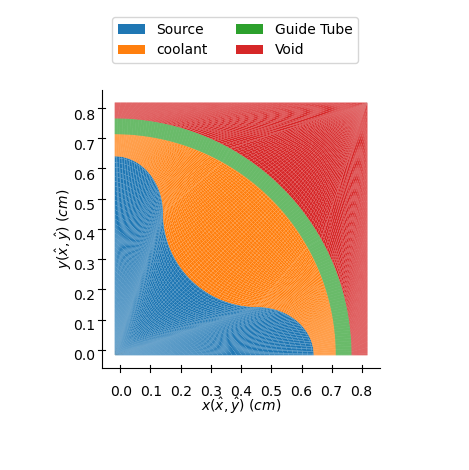

In [148]:
# Plot final mesh
ax = mesh.plot(num_nodes=128, plot_ctrlpts=False)
plt.legend(loc="upper center", ncol=2)
plt.tight_layout()
plt.savefig("./figs/four_lobe_source.png", dpi=300)
plt.show()

In [ ]:
# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    source=source
)
assembler.interp_jacobian = False
assembler.interp_jacobian_det = False
assembler.interp_boundary_jacobian_det = False
H, S, F, _, B_out = assembler.build(use_tt=True, eps=1e-10)

# Save TT information
assembler.save_tt_info("./tt_info_is.csv")

Discretization: N = 1024, G = 2, P = 1, A = 10, B = 10
Assembling Patch 1
Step            Ranks                     Compression  Elapsed Time (s)
J               1,1,1,1,1,1                  1475.76        2.91
J_det           1,1,1                          35.64        5.76
R               5,25,20,16,4                    2.81       12.00
dR              5,25,35,24,7,2                  2.95       12.00
J_detRT         5,25,20,16,4                    2.81       12.61
JdR             5,25,35,24,7,2                  2.95       13.27
Intg_int        1                              50.00       15.65
Intg_str        2,2                            33.11       15.65
H               3,3,3,3,3,5                  8801.03       15.66
S               1,1,1,1,1,1               57221064.12       15.67
Jx_det_in       1,1                             4.31       18.88
Jy_det_in       1,1                             4.31       18.88
Rx_in           1,1,1,1                        42.67       18.88
Ry_in   

In [ ]:
psi = fixed_source(
    LHS=LinearOperator([H, B_out, -S], N=assembler.N, M=assembler.M),
    RHS=LinearOperator([F], N=assembler.N, M=assembler.M),
    linear_solver_opts={
        "max_iterations": 50000,
        "threshold": 1e-10,
        "resets": 10,
    },
    device=0,
)

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy().reshape(
    (xs_server.num_groups, mesh.num_patches, -1)
)

Starting power iteration


OutOfMemoryError: CUDA out of memory. Tried to allocate 76.30 GiB. GPU 0 has a total capacity of 23.53 GiB of which 23.04 GiB is free. Including non-PyTorch memory, this process has 478.00 MiB memory in use. Of the allocated memory 14.39 MiB is allocated by PyTorch, and 7.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
# Get OpenMC solution
phi_mc = np.load("./openmc_is/data/mesh_flux.npy")

# Ensure OpenMC solution is normalized
phi_mc /= np.linalg.norm(phi_mc.flatten(), 2)

<Figure size 640x480 with 0 Axes>

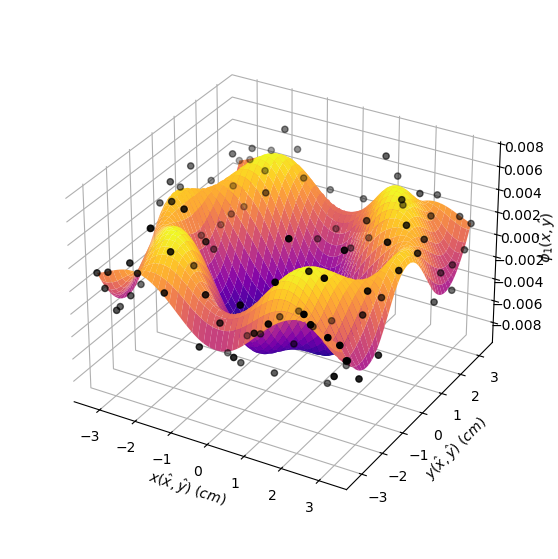

<Figure size 640x480 with 0 Axes>

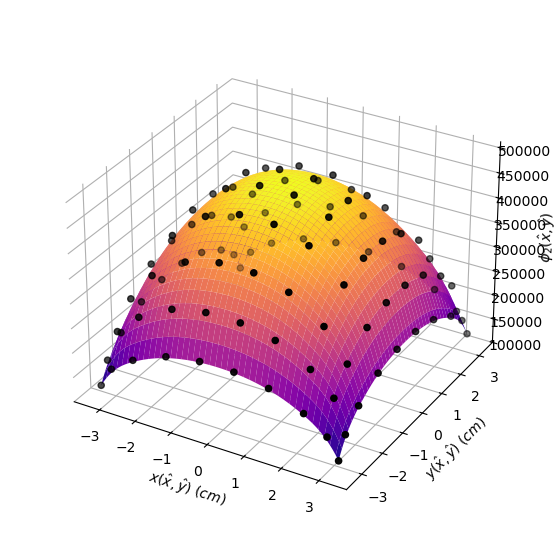

Scalar flux Relative L2-error (g = 1): 1.000000003652273
Scalar flux Relative L2-error (g = 2): 0.38822099004836014
Total scalar flux Relative L2-error: 0.7404040941374713


In [ ]:
# Map rectangular mesh
pids, coords = mesh.map_regular_mesh(shape=phi_mc.shape[1:], N=(2, 2))

# Iterate through groups and plot
phi_avg = np.zeros(phi_mc.shape)
for g in range(xs_server.num_groups):
    # Set control points
    mesh.set_phi(phi[g,])

    # Calculate regular mesh
    phi_avg[g,] = mesh.regular_mesh(pids, coords)

    # Plot
    plt.clf()
    ax = mesh.plot(plot_ctrlpts=True, use_2d=False, figsize=(7, 7))
    ax.set_zlabel(f"$\\phi_{g + 1}" + "(\\hat{x}, \\hat{y})$")
    ax.set_box_aspect(None, zoom=0.9)
    plt.savefig(f"./figs_is/phi_{g + 1}_vac.png", dpi=300)
    plt.show()

# Normalize average
phi_avg /= np.linalg.norm(phi_avg.flatten(), 2)

for g in range(xs_server.num_groups):
    # Calculate groups L2-error
    print(
        "Scalar flux Relative L2-error (g = {}): {}".format(
            g + 1, 
            np.linalg.norm(
                (phi_avg[g,] - phi_mc[g,]).flatten(), 2
            ) / np.linalg.norm(phi_mc[g,].flatten(), 2)
        )
    )
print(
    "Total scalar flux Relative L2-error: {}".format(
        np.linalg.norm(
            (phi_avg - phi_mc).flatten(), 2
        ) / np.linalg.norm(phi_mc.flatten(), 2)
    )
)